# ■ 머신러닝 컴페티션

### 컴페티션의 목표는 ① 이해, ② 풀프로세스 코딩, ③ 설명력을 키우는게 목적입니다.

데이터 출처: https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset/data

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X

※ 수업 코드 사용 가능

※ 타 온라인 상 레퍼런스 코드 참고는 가능하나, 통째 복사 금지

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. 1. 코딩의 인과성, 2. 설명, 3. 결과 해석에 따른 합당한 인사이트 제안으로 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 ML 선정 기준 (650자 이내, 주석 서술하기)

4. (25점) SHAP value 사후분석과 인사이트 제안 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

## ▶ 첫째날, 숙달 Day (감독):

### 18시 까지 코드 완성본 (주석 서술 포함) 제출 (90점) - 시험시작부터 3시간 후 휴식 가능

---

## ▶  둘째날, 포트폴리오화 Day:

### 깃허브에 코드 및 READ ME 이쁘게 정리하여 URL 제출 (10점)

## 레퍼런스 코드 (타이타닉 데이터 버전)

[I 2026-04-08 13:53:59,635] A new study created in memory with name: no-name-5f7cb8f2-a3e6-4f9a-90c8-ddfb56733470
[I 2026-04-08 13:53:59,716] Trial 0 finished with value: 0.7258064516129032 and parameters: {'n_estimators': 121, 'max_depth': 3}. Best is trial 0 with value: 0.7258064516129032.
[I 2026-04-08 13:53:59,887] Trial 1 finished with value: 0.732824427480916 and parameters: {'n_estimators': 205, 'max_depth': 12}. Best is trial 1 with value: 0.732824427480916.
[I 2026-04-08 13:54:00,070] Trial 2 finished with value: 0.6942148760330579 and parameters: {'n_estimators': 222, 'max_depth': 7}. Best is trial 1 with value: 0.732824427480916.
[I 2026-04-08 13:54:00,208] Trial 3 finished with value: 0.7166666666666667 and parameters: {'n_estimators': 181, 'max_depth': 6}. Best is trial 1 with value: 0.732824427480916.
[I 2026-04-08 13:54:00,382] Trial 4 finished with value: 0.7424242424242424 and parameters: {'n_estimators': 200, 'max_depth': 14}. Best is trial 4 with value: 0.74242424242

RF F1: 0.7368421052631579
LR F1: 0.71875
SVM F1: 0.736
KNN F1: 0.7555555555555555


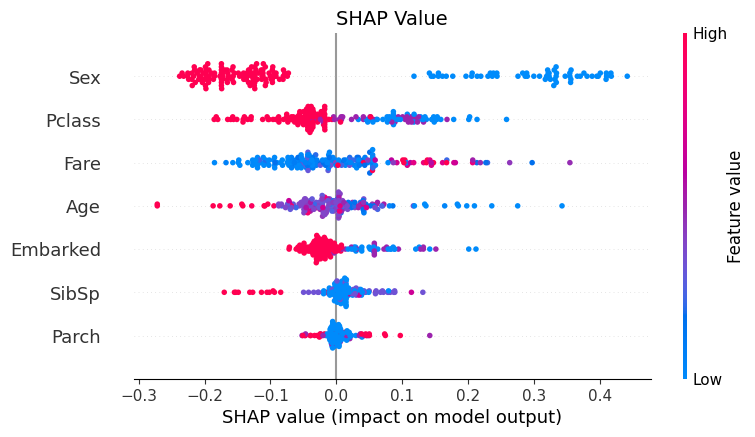

Stacking F1: 0.765625


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import optuna
import shap
import matplotlib.pyplot as plt

# 데이터 로드
df = pd.read_csv('titanic.csv')

# 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], errors='ignore')

# 결측치 처리
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 범주형 인코딩
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

# ★필독! EDA 제안 해줘야 한다.

# X, y
X = df.drop('Survived', axis=1)
y = df['Survived']

# train valid split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)


# ★필독! 모델 선정은 pycaret을 이용해서 스코어 잘나오는 모델 4개 고르기


# Optuna : 하이퍼파라미터 리스트는 구글에 각 모델 검색하면 나온다.
#          (예: 랜덤포레스트 optuna 검색)
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_lr(trial):
    params = {
        'C': trial.suggest_float('C', 0.01, 10)
    }
    model = LogisticRegression(**params, max_iter=1000)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_svm(trial):
    params = {
        'C': trial.suggest_float('C', 0.1, 10),
        'kernel': trial.suggest_categorical('kernel', ['linear', 'rbf'])
    }
    model = SVC(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_knn(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 15)
    }
    model = KNeighborsClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# 각 모델마다 옵튜나로 최적의 하이퍼파라미터 탐색
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=10)

study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=10)

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=10)

study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(objective_knn, n_trials=10)

# 옵튜나로 찾은 각각 모델의 하이퍼 파라미터로 각각 모델 옵션 정의
rf = RandomForestClassifier(**study_rf.best_params)
lr = LogisticRegression(**study_lr.best_params, max_iter=1000)
svm = SVC(**study_svm.best_params, probability=True)
knn = KNeighborsClassifier(**study_knn.best_params)

# 모델 학습
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
knn.fit(X_train, y_train)

# 반복문을 통하여 학습이 완료된 모델 꺼내와서 예측하고 f1스코어 출력
for name, model in [('RF', rf), ('LR', lr), ('SVM', svm), ('KNN', knn)]:
    pred = model.predict(X_valid)
    print(name, "F1:", f1_score(y_valid, pred))

# SHAP - 여기서 랜덤포레스트를 지정해서 사후분석 해보겠다.
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_valid)

# 모델마다 SHAP value 행렬 차원이 다르기 때문에 다르게 설정 (수업에서 강조한 내용)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
else:
    shap_values = shap_values

# SHAP  Plot 시각화
shap.summary_plot(
    shap_values, # shape value 반환
    X_valid, # 평가용 데이터로 SHAP value 측정
    feature_names=X.columns, # 컬럼리스트
    plot_type="dot",
    show=False
)
plt.title("SHAP Value", fontsize=14)
plt.show()


# 전방 모델 리스트
est_model_list = [
                      ('rf', rf),
                      ('svm', svm),
                      ('knn', knn)
                  ]


# Stacking 모델 합체
stack = StackingClassifier(
    estimators = est_model_list, # 전방모델
    final_estimator = LogisticRegression() # 후방모델
)

stack.fit(X_train, y_train)

pred = stack.predict(X_valid)
print("Stacking F1:", f1_score(y_valid, pred))

# 전체 코드 하단 작성

## ※ 심플한 코드로는 F1 score가 57정도 나오는 데이터

In [ ]:
# 우선 상위 모델 4개를 pycaret으로 먼저 구해보자
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 2. 데이터 로드
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 3. 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['customer_id'], errors='ignore')

# 범주형 인코딩
le_country = LabelEncoder()
le_gender = LabelEncoder()

df['country'] = le_country.fit_transform(df['country'])
df['gender'] = le_gender.fit_transform(df['gender'])


# split
train_df, valid_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['churn'])

from pycaret.classification import *

# PyCaret 설정
clf = setup(
              data          = train_df, # 학습할 데이터프레임 (피처랑 정답 같이 있어야함)
              target        = "churn",
              session_id    = 42,
              verbose       = True
            )

# Step 1. 모든 모델 비교 - F1 기준으로 베스트 모델 선택
best_model = compare_models(sort="F1")

# 모델비교 결과 나오면 4개 확인하고 끝.

# ====================== 최종 제출 답안 ======================

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import optuna
import shap
import matplotlib.pyplot as plt

# 데이터 로드 및 전처리 (EDA)

### 데이터 로드

In [3]:
import pandas as pd
df = pd.read_csv('Bank Customer Churn Prediction.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'Bank Customer Churn Prediction.csv'

### 불필요한 컬럼 제거, 범주형 인코딩, EDA 제안

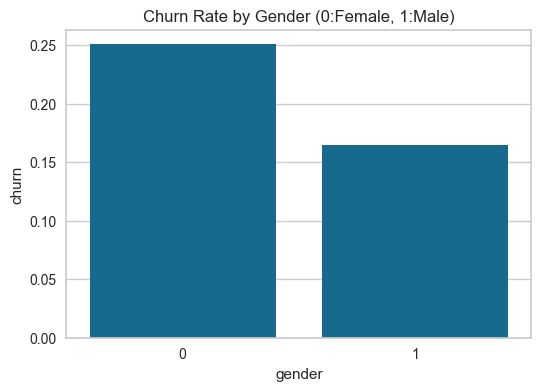

gender
0    0.250715
1    0.164559
Name: churn, dtype: float64


In [ ]:
# 필요없는 컬럼 제거
df = df.drop(columns=['customer_id'], errors='ignore')          # customer_id는 단순 식별자라 예측에 의미 없음 -> 제거

# 결측치 처리
# df.info()                                                     # 결측치 없음 -> 별도 처리 불필요

# 범주형 인코딩
# country, gender는 문자열이라 모델이 바로 읽지 못함 -> 숫자로 변환 필요
le_country = LabelEncoder()
le_gender = LabelEncoder()

df['country'] = le_country.fit_transform(df['country'])
df['gender'] = le_gender.fit_transform(df['gender'])

# EDA : 성별에 따른 이탈률 시각화 (성별(x)별 평균 이탈률(y) 막대 그래프)
import matplotlib.pyplot as plt     
import seaborn as sns

plt.figure(figsize=(6, 4))  
sns.barplot(x='gender', y='churn', data=df, ci=None)
plt.title('Churn Rate by Gender (0:Female, 1:Male)')
plt.show()                                                      # 결과 : 여성(0)의 이탈률이 남성(1)보다 높게 나타남    


import matplotlib.pyplot as plt     
import seaborn as sns

plt.figure(figsize=(6, 4))  
ax = sns.barplot(x='gender', y='churn', data=df, ci=None)

# 막대 위에 수치 표시
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}',          # 0.25 → 25.1% 형식
                (p.get_x() + p.get_width() / 2,   # x: 막대 중앙
                 p.get_height()),                  # y: 막대 꼭대기
                ha='center', va='bottom',          # 가운데 정렬, 막대 위
                fontsize=12, fontweight='bold')

plt.title('Churn Rate by Gender (0:Female, 1:Male)')
plt.show()






print(df.groupby('gender')['churn'].mean())

### (20점) EDA를 통한 타당한 해석 (650자 이내)

#### 성별(gender)에 따른 이탈률(churn)을 분석한 결과, 여성(0)의 이탈률은 약 25.1%, 남성(1)은 약 16.5%로 여성이 약 8.6%p 더 높게 나타났다. 이는 성별이 고객 이탈 여부를 예측하는 데 유의미한 변수임을 시사한다. 여성 고객이 상대적으로 이탈에 더 민감하게 반응하는 원인으로는 금융 상품의 니즈 차이, 서비스 만족도 차이, 경쟁 은행으로의 이동 가능성 등을 고려할 수 있다. 따라서 모델 학습 시 gender 변수를 중요한 피처로 포함하는 것이 타당하다.


### 데이터 분할, 스케일링

In [ ]:
# train valid split
y = df['churn']     # 정답값(이탈 여부)인 'churn' 컬럼을 y에 저장
train_df, valid_df = train_test_split(df, test_size=0.2, random_state=42, stratify=y)

# 스케일링 : 피처 값의 크기 차이를 제거해 모델 학습 안정화
scaler = StandardScaler()

X = train_df.columns.drop('churn')  # 정답(churn) 제외한 피처 컬럼 목록

train_df[X] = scaler.fit_transform(train_df[X])     # train 데이터 기준으로 스케일링 (기준 저장)
valid_df[X] = scaler.transform(valid_df[X])         # 저장된 기준을 valid에도 똑같이 적용

### (15점) 전처리 아이디어 적합성 + 논리 (650자 이내)

##### (1) 불필요한 컬럼 제거 : customer_id는 단순 고객 식별자로, 이탈 여부와 인과관계가 없는 변수이다. 이를 학습에 포함할 경우 모델이 의미 없는 패턴을 학습할 수 있으므로 제거하였다.
##### (2) 범주형 변수 인코딩 : country와 gender는 문자열 범주형 변수로, 머신러닝 모델은 수치형 입력만 처리할 수 있다. 따라서 LabelEncoder를 적용해 수치형으로 변환하였다.
##### (3) Train/Validation 분리 및 StandardScaler 적용 : 데이터를 8:2로 분리할 때 stratify=y를 적용하여 클래스 불균형 문제로 인한 평가 왜곡을 방지하였다. 스케일링은 fit_transform을 학습셋에만 적용하고 검증셋에는 transform만 수행함으로써 데이터 누수를 차단하였다.

### PyCaret 설정, 모델 비교 및 결과

In [ ]:
from pycaret.classification import *

clf = setup(
              data          = train_df,       # 학습 데이터 (피처 + 정답 포함)
              target        = "churn",        # 예측할 정답 컬럼
              session_id    = 42,             # 재현성을 위한 시드 고정
              verbose       = True
            )

# 모든 모델 비교 - F1 기준으로 베스트 모델 선택
best_model = compare_models(sort="F1")

,Description,Value
0,Session id,42
1,Target,churn
2,Target type,Binary
3,Original data shape,"(8000, 11)"
4,Transformed data shape,"(8000, 11)"
5,Transformed train set shape,"(5600, 11)"
6,Transformed test set shape,"(2400, 11)"
7,Numeric features,10
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.8555,0.8496,0.4804,0.7197,0.5748,0.4921,0.5074,0.0190
gbc,Gradient Boosting Classifier,0.8612,0.8639,0.4549,0.7724,0.5705,0.4946,0.5203,0.0530
lightgbm,Light Gradient Boosting Machine,0.8539,0.8495,0.4751,0.7147,0.5685,0.4852,0.5010,0.3080
rf,Random Forest Classifier,0.8586,0.8445,0.4436,0.7625,0.5599,0.4829,0.5084,0.0500
et,Extra Trees Classifier,0.8550,0.8419,0.4322,0.7525,0.5478,0.4691,0.4952,0.0350
dt,Decision Tree Classifier,0.7843,0.6771,0.4961,0.4723,0.4835,0.3474,0.3478,0.0060
knn,K Neighbors Classifier,0.8280,0.7773,0.3725,0.6352,0.4677,0.3737,0.3936,0.0100
qda,Quadratic Discriminant Analysis,0.8457,0.8155,0.3243,0.8001,0.4600,0.3887,0.4434,0.0040
nb,Naive Bayes,0.8348,0.8115,0.2604,0.7861,0.3897,0.3216,0.3881,0.0040
lda,Linear Discriminant Analysis,0.8079,0.7611,0.2112,0.5783,0.3086,0.2244,0.2633,0.0040


### (25점) Feature Selection과 ML 선정 기준 (650자 이내)

##### (1) Feature Selection — 별도의 자동화된 feature selection 기법은 적용하지 않았으나, 도메인 지식에 기반하여 고객 이탈 예측과 무관한 customer_id를 사전에 제거하였다. 이는 수동 feature selection에 해당한다. 나머지 10개 수치형 피처는 모두 이탈 예측에 잠재적 영향을 가질 수 있다고 판단하여 전부 사용하였다.

##### (2) ML 모델 선정 기준 — PyCaret으로 14개 모델의 F1 Score를 한 번에 비교한 뒤, F1 Score 상위 4개 모델인 Ada Boost, Gradient Boosting, LightGBM, Random Forest를 선정하였다. 이탈 예측은 클래스 불균형이 존재하는 이진 분류 문제이므로 Accuracy보다 Precision과 Recall을 균형 있게 반영하는 F1이 더 적합한 기준이다.

# 상위 모델 4개 -> 각 모델 optuna로 최적의 파라미터 찾기

In [ ]:
# 모델 4개 :
# 1. ada(Ada Boost Classifier)
# 2. gbc(Gradient Boosting Classifier)
# 3. lightgbm(Light Gradient Boosting Machine)
# 4. rf(Random Forest Classifier)

### 각 모델마다 optuna로 최적의 하이퍼파라미터 탐색

In [ ]:
# 1. ada : Ada Boost Classifier
def objective_ada(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),             # 트리 개수 탐색 범위
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0)        # 학습률 탐색 범위
    }
    model = AdaBoostClassifier(**params, random_state=42)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)                                              # F1이 높을수록 좋은 파라미터

# 2. gbc : Gradient Boosting Classifier
def objective_gbc(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.5),
        'max_depth': trial.suggest_int('max_depth', 3, 10)                      # 트리 깊이 (깊을수록 복잡한 패턴 학습)
    }
    model = GradientBoostingClassifier(**params, random_state=42)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# 3. lightgbm : Light Gradient Boosting Machine
def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.5),
        'max_depth': trial.suggest_int('max_depth', 3, 15)
    }
    model = LGBMClassifier(**params, random_state=42, verbose=-1)                # verbose=-1: 학습 로그 숨김
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# 4. rf : Random Forest Classifier
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
    }
    model = RandomForestClassifier(**params, random_state=42)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

In [ ]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from lightgbm import LGBMClassifier

# 정답(churn)을 분리해서 X(피처), y(정답) 준비
X_train = train_df.drop(columns=['churn'])
y_train = train_df['churn']
X_valid = valid_df.drop(columns=['churn'])
y_valid = valid_df['churn']

# F1을 최대화하는 방향으로 탐색
study_ada = optuna.create_study(direction='maximize')          
study_ada.optimize(objective_ada, n_trials=10)

study_gbc = optuna.create_study(direction='maximize')
study_gbc.optimize(objective_gbc, n_trials=10)

study_lgbm = optuna.create_study(direction='maximize')
study_lgbm.optimize(objective_lgbm, n_trials=10)

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=10)

[I 2026-04-09 16:38:40,555] A new study created in memory with name: no-name-f64fb43d-6553-4ffc-ad99-5a470ec3c285
[I 2026-04-09 16:38:41,167] Trial 0 finished with value: 0.530278232405892 and parameters: {'n_estimators': 232, 'learning_rate': 0.060053538335564746}. Best is trial 0 with value: 0.530278232405892.
[I 2026-04-09 16:38:41,816] Trial 1 finished with value: 0.5770392749244713 and parameters: {'n_estimators': 254, 'learning_rate': 0.1488966167163777}. Best is trial 1 with value: 0.5770392749244713.
[I 2026-04-09 16:38:42,047] Trial 2 finished with value: 0.5663716814159292 and parameters: {'n_estimators': 90, 'learning_rate': 0.9861155738626162}. Best is trial 1 with value: 0.5770392749244713.
[I 2026-04-09 16:38:42,260] Trial 3 finished with value: 0.49220103986135183 and parameters: {'n_estimators': 82, 'learning_rate': 0.10030782701804722}. Best is trial 1 with value: 0.5770392749244713.
[I 2026-04-09 16:38:42,791] Trial 4 finished with value: 0.5718518518518518 and parame

### optuna로 찾은 각각 모델의 하이퍼파라미터로 각각 모델 옵션 정의

In [34]:
ada = AdaBoostClassifier(**study_ada.best_params, random_state=42)
gbc = GradientBoostingClassifier(**study_gbc.best_params, random_state=42)
lgbm = LGBMClassifier(**study_lgbm.best_params, random_state=42, verbose=-1)
rf = RandomForestClassifier(**study_rf.best_params, random_state=42)

### 모델 학습

In [ ]:
ada.fit(X_train, y_train)
gbc.fit(X_train, y_train)
lgbm.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=13, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=168, n_jobs=None,
                       oob_score=False, random_state=42, verbose=0,
                       warm_start=False)

### 학습이 완료된 모델의 검증 데이터 f1스코어 출력

In [36]:
for name, model in [('ADA', ada), ('GBC', gbc), ('LGBM', lgbm), ('RF', rf)]:
    pred = model.predict(X_valid)
    print(name, "F1:", f1_score(y_valid, pred))

ADA F1: 0.5794947994056464
GBC F1: 0.5945121951219512
LGBM F1: 0.593939393939394
RF F1: 0.5808477237048666


# SHAP Value 시각화 및 4개 모델의 Stacking

### 모델 4개 중 1개의 SHAP Value 시각화

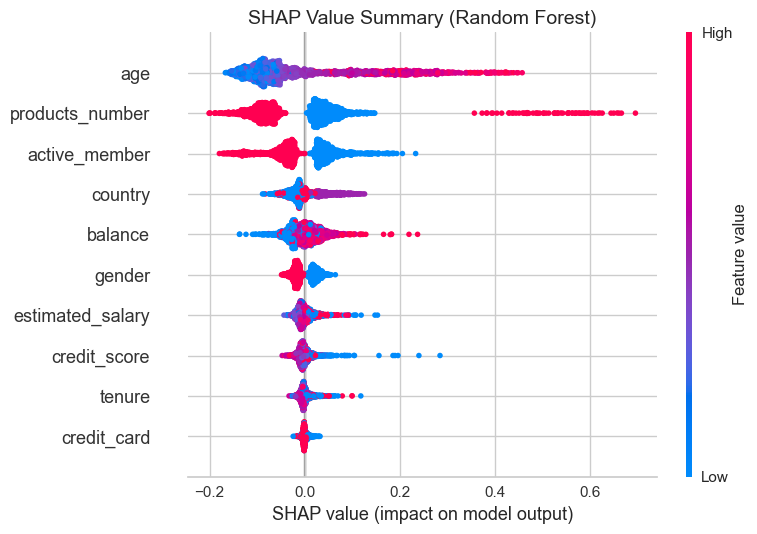

In [ ]:
# SHAP 사후 분석 (Random Forest 기준) (어떤 피처가 이탈 예측에 얼마나 영향을 줬는지 확인)
explainer = shap.TreeExplainer(rf)               # RF 모델 기반 SHAP 계산기 생성
shap_values = explainer.shap_values(X_valid)     # 검증 데이터에 대한 SHAP 값 계산

# SHAP 값 형태에 따라 이탈(1) 클래스 기준으로 추출
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
else:
    shap_values = shap_values

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,         
    X_valid,              
    feature_names=X,      # 피처 이름 표시
    plot_type="dot",      # 점 형태로 각 데이터 포인트의 영향력 표시
    show=False          
)

plt.title("SHAP Value Summary (Random Forest)", fontsize=14)
plt.tight_layout()
plt.show()

### (25점) SHAP value 사후분석과 인사이트 제안 (650자 이내)

Random Forest 모델을 기준으로 SHAP Value를 분석한 결과, 고객 이탈에 가장 큰 영향을 미치는 변수는 age, products_number, active_member 순으로 나타났다.

##### (1) age — Feature value가 높을수록(고령) SHAP 값이 양의 방향으로 크게 분포하여, 나이가 많을수록 이탈 가능성이 높아짐을 확인할 수 있다. 분포 범위가 가장 넓어 예측에 가장 강한 영향력을 보인다.
##### (2) products_number — 보유 상품 수가 낮은 경우(파란색)와 매우 높은 경우(빨간색) 모두 이탈 방향으로 작용하는 비선형적 패턴을 보인다.
##### (3) active_member — 비활성 고객(파란색)이 양의 SHAP 값을 가져, 활동하지 않는 고객일수록 이탈 가능성이 높다.

---> 인사이트 제안 : 위의 세 가지 특징을 고려해보면 고령 고객 대상 맞춤 케어 프로그램 운영, 상품 포트폴리오 최적화(2~3개 상품 유지 유도), 비활성 고객에 대한 재참여 캠페인을 통한 이탈 방지 전략이 효과적일 것으로 판단된다.

### 4개 모델 Stacking 및 f1, accurancy score 출력

In [39]:
from sklearn.metrics import f1_score, accuracy_score

# 전방 모델 리스트
est_model_list = [
    ('ada', ada),
    ('gbc', gbc),
    ('lgbm', lgbm),
    ('rf', rf)
]

# Stacking 모델 합체
stack = StackingClassifier(
    estimators = est_model_list,                # 전방 모델
    final_estimator = LogisticRegression()      # 후방 모델
)

stack.fit(X_train, y_train)


pred = stack.predict(X_valid)
print(f"★ Stacking Final Validation F1-Score: {f1_score(y_valid, pred):.4f}")
print(f"★ Stacking Final Validation Accuracy: {accuracy_score(y_valid, pred):.4f}")

★ Stacking Final Validation F1-Score: 0.5918
★ Stacking Final Validation Accuracy: 0.8655


### (5점) validation score 적절하게 출력 (300자 이내)

##### ADA, GBC, LGBM, RF 4개 모델을 전방 모델로, Logistic Regression을 최종 판단 모델로 구성한 Stacking 앙상블의 최종 성능은 F1-Score 0.5918, Accuracy 0.8655를 기록하였다. 이는 PyCaret 비교 단계에서 가장 높은 F1을 보인 Ada Boost(0.5748)보다 향상된 수치로, 개별 모델의 예측 결과를 결합함으로써 단일 모델의 한계를 보완하는 앙상블의 효과가 유효하게 작용하였음을 확인할 수 있다.